In [148]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
import qkd_sf as qsf
from importlib import reload
import plotly.graph_objects as go

In [158]:
import plotly.io as pio

pio.renderers.default = "notebook"

In [157]:
def reload_protocols():
    reload(qsf)

In [176]:
eta_grid = np.linspace(0, 1, 3)
keylen = 1000
var_a_grid = np.linspace(0.001, 100, 5)
V_grid = np.linspace(0.1, 1, 5)

### Mutual Information

In [177]:
reload_protocols()
I_per_eta_dict_th = qsf.get_mutual_information_th(var_a_grid, V_grid, eta_grid)

Progress: 3/3

In [178]:
reload_protocols()
I_per_eta_dict_MC = qsf.get_mutual_information_MC(var_a_grid, V_grid, eta_grid, keylen)

Progress: 3/3

## RR Protocol

### Holevo Bound

In [180]:
reload_protocols()
chix_per_eta_dict_RR = qsf.get_Holevo_bound(var_a_grid, V_grid, eta_grid, 'RR')

Progress: 3/3

### 3D Plots

In [184]:
b=0.9
eta_RR = 0.5

th_I_grid_x_RR = I_per_eta_dict_th[f'eta_{eta_RR}']
th_chi_x_grid_RR = chix_per_eta_dict_RR[f'eta_{eta_RR}']

I_grid_x_RR = I_per_eta_dict_MC[f'eta_{eta_RR}']
chi_x_grid_RR = chix_per_eta_dict_RR[f'eta_{eta_RR}']

fig = go.Figure()
V_mesh, var_a_mesh = np.meshgrid(V_grid, var_a_grid)
fig.add_trace(go.Scatter3d(x=V_mesh.ravel(), y=var_a_mesh.ravel(), z=I_grid_x_RR.ravel(), mode='markers', marker=dict(size=3, color='blue')))
fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_I_grid_x_RR, surfacecolor=np.zeros_like(th_I_grid_x_RR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_chi_x_grid_RR, surfacecolor=np.zeros_like(th_chi_x_grid_RR), colorscale=[[0.0, 'red'], [1.0, 'red']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title=r"var_a", zaxis = dict(title="Info"), aspectmode ="cube"), width=900, height=750)

fig.show()
        

In [185]:
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=b*th_I_grid_x_RR-th_chi_x_grid_RR, surfacecolor=np.zeros_like(b*th_I_grid_x_RR-th_chi_x_grid_RR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title="var_a", zaxis = dict(title="K", range=[0, None]), aspectmode ="cube"), width=900, height=750)
fig.show()
        

### Plot Mutual Information & Holevo Bound

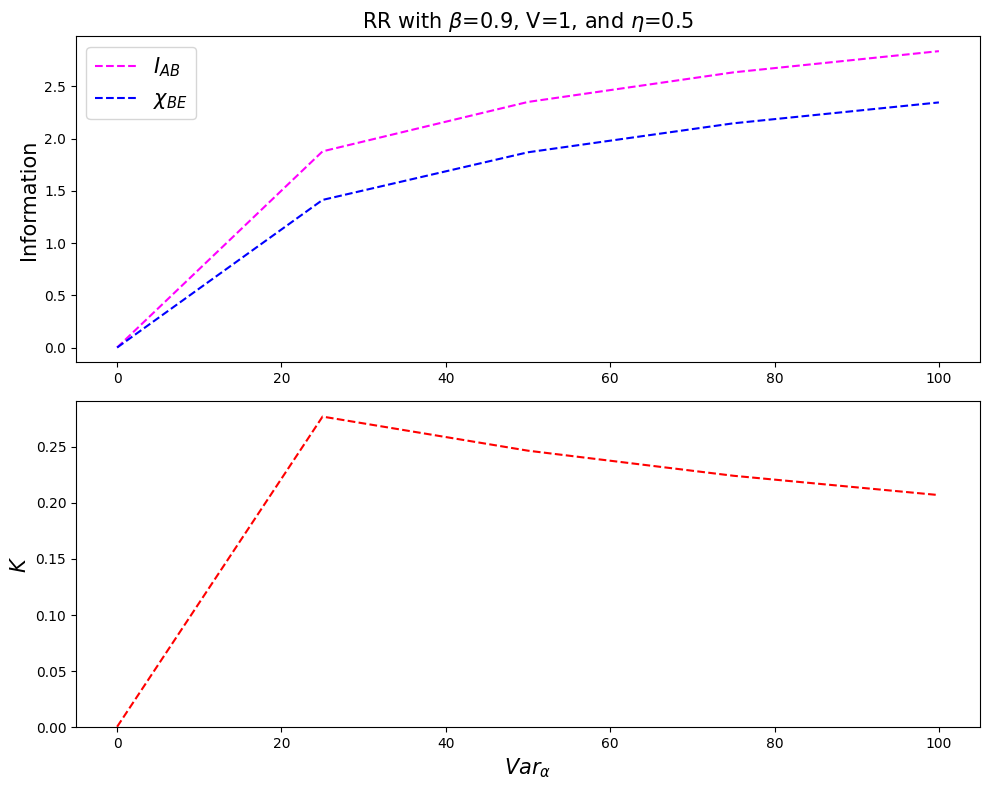

In [187]:
reload_protocols()

V=1
b = 0.9
idx = np.where(V_grid==V)[0][0]
th_I_x_RR = (th_I_grid_x_RR[:, idx])
th_chi_x_RR = (th_chi_x_grid_RR[:, idx])


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), dpi=100)

ax[0].set_title(rf'RR with $\beta$={b}, V={V}, and $\eta$={eta_RR}', fontsize=15)
#ax[0].scatter(var_a_grid, I_x_RR, s=15, color = 'magenta')
ax[0].plot(var_a_grid, th_I_x_RR, '--', color='magenta', label=r'$I_{AB}$')
ax[0].plot(var_a_grid, th_chi_x_RR, 'b--', label=r'$\chi_{BE}$')
ax[0].set_ylabel(r'Information', fontsize=15)
ax[0].legend(fontsize=15)

ax[1].plot(var_a_grid, qsf.key_rate(b,  th_I_x_RR, th_chi_x_RR), '--r', label = f'Key-Rate')
#ax[1].scatter(var_a_grid, qsf.key_rate(b, I_x_RR, th_chi_x_RR), s=15, color = 'red', label = f'MC Key-Rate')
ax[1].set_xlabel(r'$Var_{{\alpha}}$', fontsize=15)
ax[1].set_ylim(0)
ax[1].set_ylabel(r'$K$', fontsize=15)
plt.tight_layout()



In [145]:
bs = np.linspace(0.0, 1, 2000)
low_b_cs_RR=np.ones((len(eta_grid)))

for i,eta_DR in enumerate(eta_grid):
    th_I_grid_x_RR = I_per_eta_dict_th[f'eta_{eta_DR}'][:, -1]
    th_chi_x_grid_RR = chix_per_eta_dict_RR[f'eta_{eta_DR}'][:, -1]
    for b in bs:
        K_grid = qsf.key_rate(b, th_I_grid_x_RR, th_chi_x_grid_RR)
        max_value = np.nanmax(K_grid)
        if max_value>=1e-3:
            low_b_cs_RR[i]=b
            break


In [146]:
bs = np.linspace(0.0, 1, 2000)
low_b_RR=np.ones((len(eta_grid)))

for i,eta_DR in enumerate(eta_grid):
    th_I_grid_x_RR = I_per_eta_dict_th[f'eta_{eta_DR}']
    th_chi_x_grid_RR = chix_per_eta_dict_RR[f'eta_{eta_DR}']
    for b in bs:
        K_grid = qsf.key_rate(b, th_I_grid_x_RR, th_chi_x_grid_RR)
        max_value = np.nanmax(K_grid)
        if max_value>=1e-3:
            low_b_RR[i]=b
            break


Text(0, 0.5, '$b_{th}$')

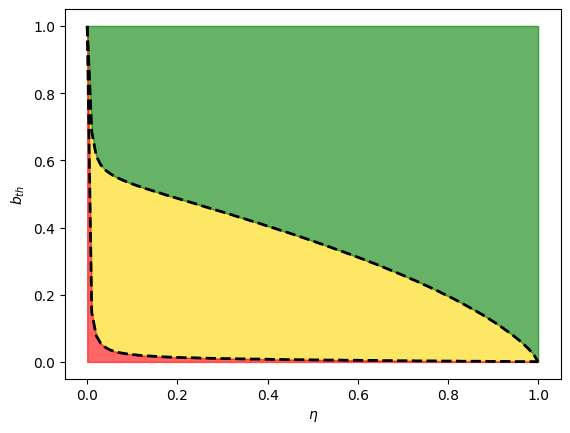

In [147]:
plt.plot(eta_grid, low_b_RR, '--', color='k', linewidth=2)
plt.plot(eta_grid, low_b_cs_RR, '--', color='k', linewidth=2)
plt.fill_between(eta_grid, low_b_RR, low_b_cs_RR, color='gold', alpha=0.6)
plt.fill_between(eta_grid, low_b_cs_RR, 1, color='green', alpha=0.6)
plt.fill_between(eta_grid, low_b_RR, 0, color='red', alpha=0.6)
plt.xlabel(r'$\eta$')
plt.ylabel(r'$b_{th}$')

## DR protocol

### Holevo Bound

In [49]:
reload_protocols()
chix_per_eta_dict_DR = qsf.get_Holevo_bound(var_a_grid, V_grid, eta_grid, 'DR')

Progress: 101/101

### 3D Plots

In [120]:
b=0.8
eta_DR = 0.6

th_I_grid_x_DR = I_per_eta_dict_th[f'eta_{eta_DR}']
th_chi_x_grid_DR = chix_per_eta_dict_DR[f'eta_{eta_DR}']
K_DR = qsf.key_rate(b, th_I_grid_x_DR, th_chi_x_grid_DR)

In [121]:
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)
#fig.add_trace(go.Scatter3d(x=V_mesh.ravel(), y=var_a_mesh.ravel(), z=I_grid_x_DR.ravel(), mode='markers', marker=dict(size=3, color='blue')))
fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_I_grid_x_DR, surfacecolor=np.zeros_like(th_I_grid_x_DR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_chi_x_grid_DR, surfacecolor=np.zeros_like(th_chi_x_grid_DR), colorscale=[[0.0, 'red'], [1.0, 'red']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title="var_a", zaxis = dict(title="Info"), aspectmode ="cube"), width=900, height=750)

fig.show()

In [122]:
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z= K_DR))
fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=0*(th_I_grid_x_DR-th_chi_x_grid_DR)))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title="var_a", zaxis = dict(title="K"), aspectmode ="cube"), width=900, height=750)
fig.show()

### Plot Mutual Information & Holevo Bound

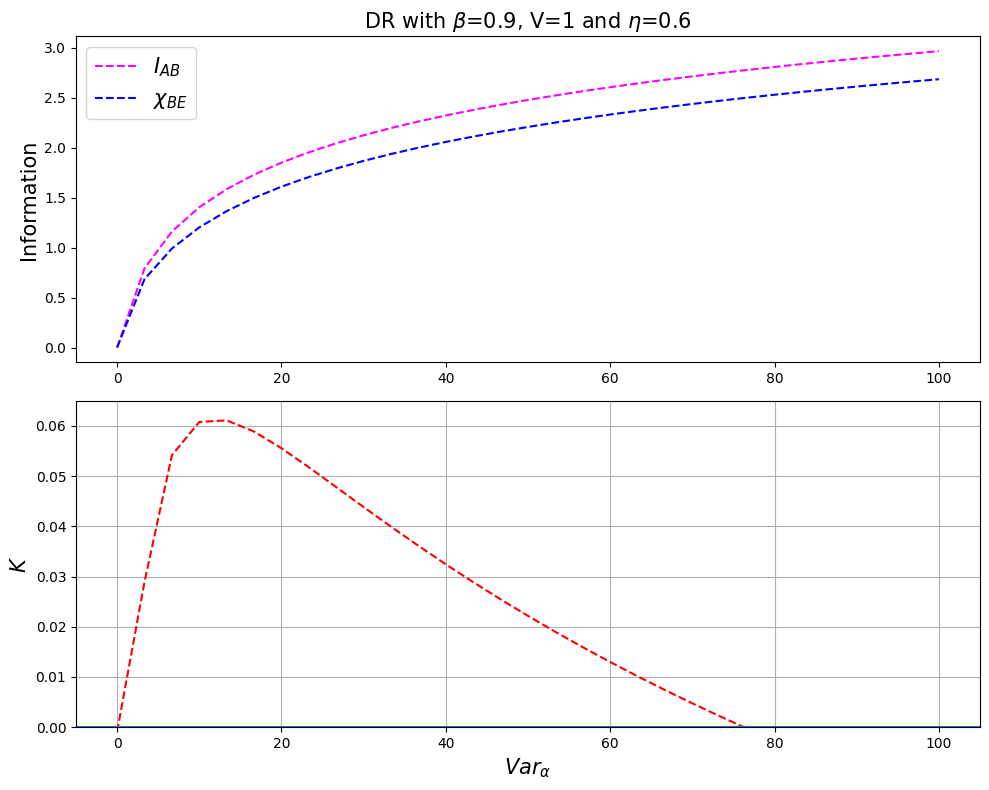

In [30]:
reload_protocols()

V=1

idx = np.where(V_grid==V)[0][0]
th_I_x_DR = (th_I_grid_x_DR[:, idx])
th_chi_x_DR = (th_chi_x_grid_DR[:, idx])

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), dpi=100)

ax[0].set_title(rf'DR with $\beta$={b}, V={V} and $\eta$={eta_DR}', fontsize=15)
#ax[0].scatter(var_a_grid, I_x_DR, s=15, color = 'magenta')
ax[0].plot(var_a_grid, th_I_x_DR, '--', color='magenta', label=r'$I_{AB}$')
ax[0].plot(var_a_grid, th_chi_x_DR, 'b--', label=r'$\chi_{BE}$')
ax[0].set_ylabel(r'Information', fontsize=15)
ax[0].legend(fontsize=15)

ax[1].plot(var_a_grid, qsf.key_rate(b,  th_I_x_DR, th_chi_x_DR), '--r', label = f'Key-Rate')
#ax[1].scatter(var_a_grid, qsf.key_rate(b, I_x_DR, th_chi_x_DR), s=15, color = 'red', label = f'MC Key-Rate')
ax[1].axhline(0)
ax[1].set_xlabel(r'$Var_{{\alpha}}$', fontsize=15)
ax[1].set_ylim(0)
ax[1].set_ylabel(r'$K$', fontsize=15)
plt.grid(True)
plt.tight_layout()



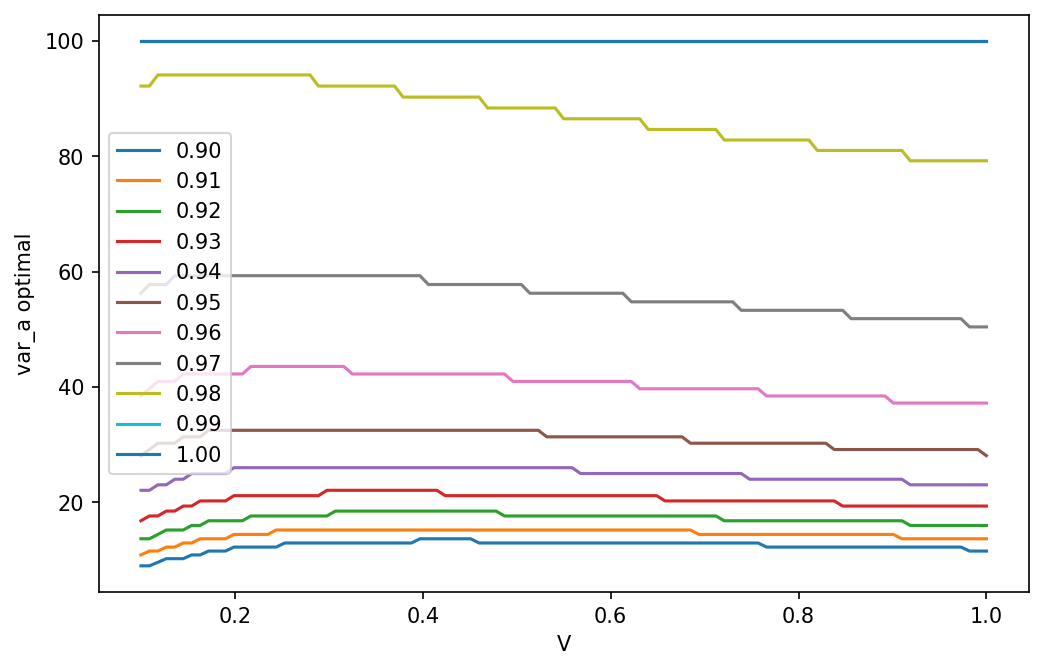

In [13]:
def var_a_optimal_data(I, chi, bs, var_a) -> dict:

    var_a_opt_dict = {}

    for b in bs:
        K = qsf.key_rate(b, I, chi)
        idx = np.nanargmax(K, axis=0)
        var_a_opt = var_a[idx]
        var_a_opt_dict[f'b_{b}'] = var_a_opt

    return var_a_opt_dict

bs = np.linspace(0.90, 1, 11)
var_a_opt_dict = var_a_optimal_data(th_I_grid_x_DR, th_chi_x_grid_DR, bs, var_a_grid)

fig = plt.figure(figsize=(8, 5), dpi=150)
for b in bs:
    plt.plot(V_grid, var_a_opt_dict[f'b_{b}'], label=f'{b:.2f}')
plt.xlabel('V')
plt.ylabel('var_a optimal')
plt.legend()


In [110]:
bs = np.linspace(0.0, 1, 2000)
low_b_DR = np.ones((len(eta_grid)))
for i,eta_DR in enumerate(eta_grid):
    th_I_grid_x_DR = I_per_eta_dict_th[f'eta_{eta_DR}']
    th_chi_x_grid_DR = chix_per_eta_dict_DR[f'eta_{eta_DR}']
    for b in bs:
        K_grid = qsf.key_rate(b, th_I_grid_x_DR, th_chi_x_grid_DR)
        max_value = np.nanmax(K_grid)
        if max_value>=1e-3:
            low_b_DR[i]=b
            break


In [123]:
bs = np.linspace(0.0, 1, 2000)
low_b_cs_DR = np.ones((len(eta_grid)))
for i,eta_DR in enumerate(eta_grid):
    th_I_grid_x_DR = I_per_eta_dict_th[f'eta_{eta_DR}'][:, -1]
    th_chi_x_grid_DR = chix_per_eta_dict_DR[f'eta_{eta_DR}'][:, -1]
    for b in bs:
        K_grid = qsf.key_rate(b, th_I_grid_x_DR, th_chi_x_grid_DR)
        max_value = np.nanmax(K_grid)
        if max_value>=1e-3:
            low_b_cs_DR[i]=b
            break


Text(0, 0.5, '$b_{th}$')

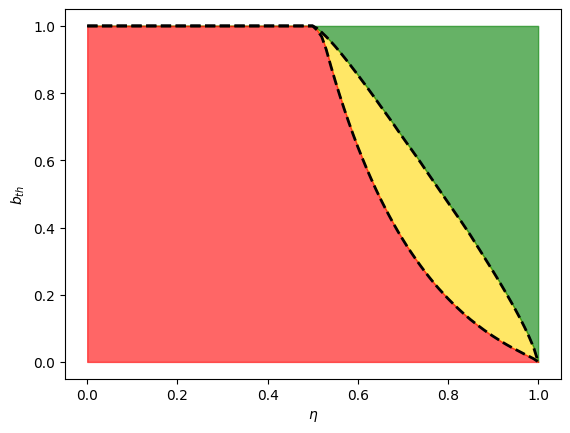

In [135]:
plt.plot(eta_grid, low_b_DR, '--', color='k', linewidth=2)
plt.plot(eta_grid, low_b_cs_DR, '--', color='k', linewidth=2)
plt.fill_between(eta_grid, low_b_DR, low_b_cs_DR, color='gold', alpha=0.6)
plt.fill_between(eta_grid, low_b_cs_DR, 1, color='green', alpha=0.6)
plt.fill_between(eta_grid, low_b_DR, 0, color='red', alpha=0.6)
plt.xlabel(r'$\eta$')
plt.ylabel(r'$b_{th}$')